Shape: (1025, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 no

/tmp/ipykernel_12004/2343152263.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=df, palette="Set2")


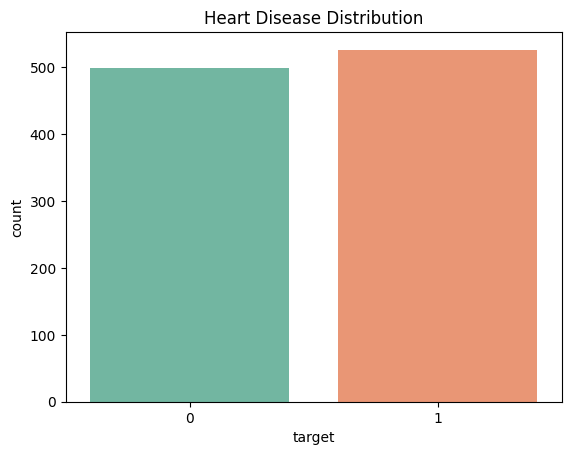

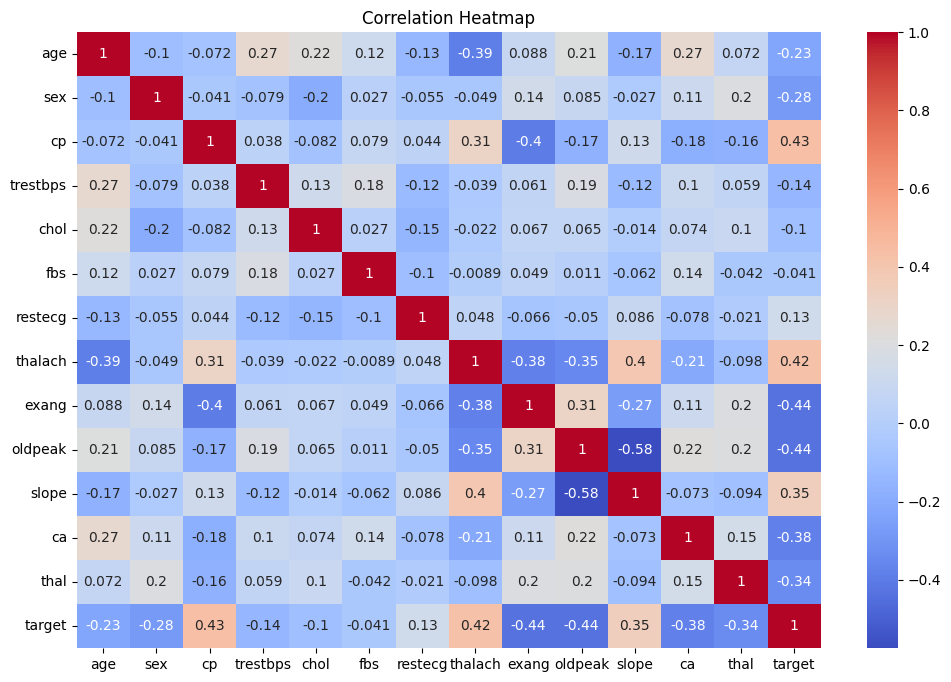

In [7]:
# Healthcare Predictive Analytics - Heart Disease Prediction
# Dataset: heart.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, classification_report

# 1. Load Data

df = pd.read_csv("/content/heart.csv")
print("Shape:", df.shape)
print(df.head())

# 2. Exploratory Data Analysis

print(df.info())
print(df.describe())

# Target distribution
sns.countplot(x="target", data=df, palette="Set2")
plt.title("Heart Disease Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# 3. Features & Target

X = df.drop("target", axis=1)
y = df["target"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# 5. Model Building

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }



                     Accuracy  Precision    Recall        F1
Logistic Regression  0.805195   0.763314  0.865772  0.811321
Decision Tree        0.844156   0.772973  0.959732  0.856287
Random Forest        0.980519   1.000000  0.959732  0.979452
Gradient Boosting    0.951299   0.946667  0.953020  0.949833


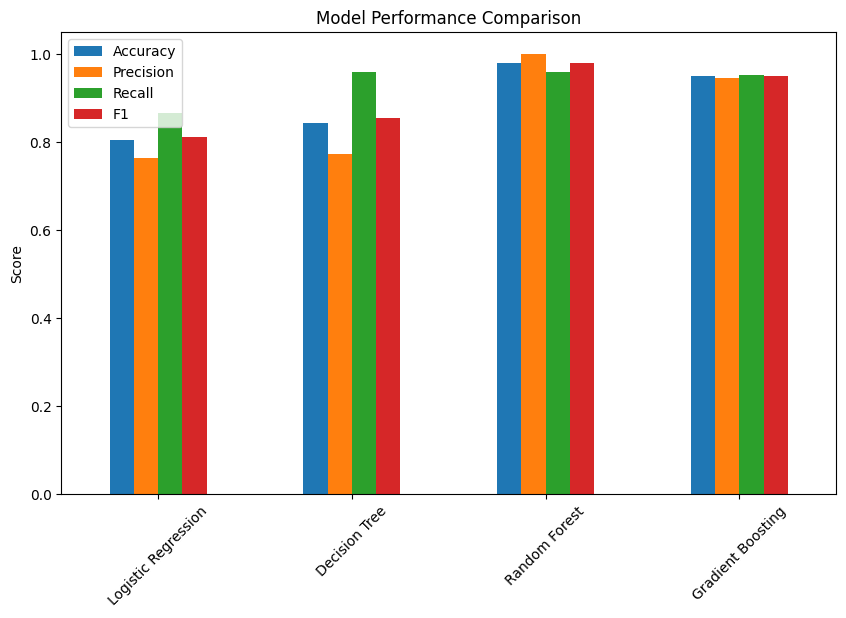

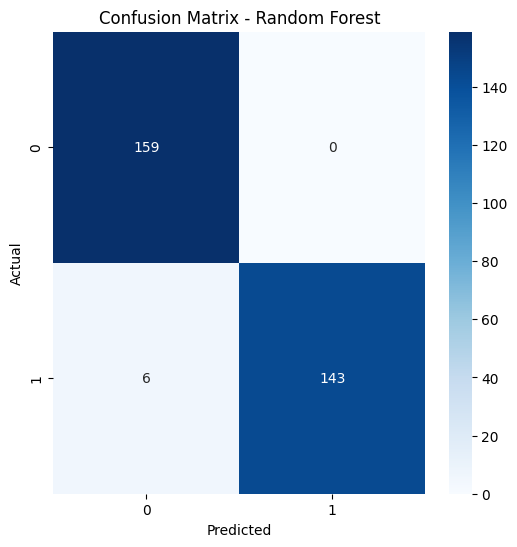

Classification Report - Random Forest:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       159
           1       1.00      0.96      0.98       149

    accuracy                           0.98       308
   macro avg       0.98      0.98      0.98       308
weighted avg       0.98      0.98      0.98       308



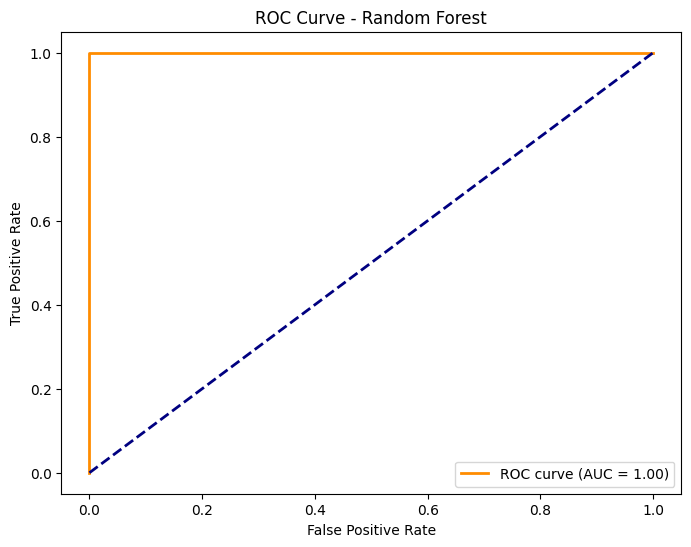

/tmp/ipykernel_12004/1443088342.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")


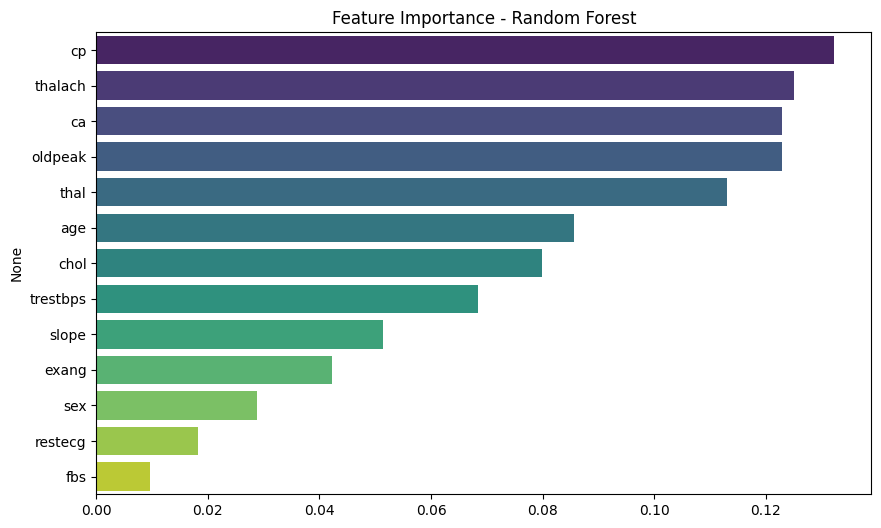

In [8]:
# 6. Evaluation Results

results_df = pd.DataFrame(results).T
print(results_df)

# Bar chart of model performance
results_df.plot(kind="bar", figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

# 7. Confusion Matrix (Random Forest)

rf_model = models["Random Forest"]
y_pred_rf = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Classification Report - Random Forest:\n", classification_report(y_test, y_pred_rf))

# 8. ROC Curve

y_prob = rf_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.show()


# 9. Feature Importance

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")
plt.title("Feature Importance - Random Forest")
plt.show()



In [9]:
# 10. Cross-Validation

cv_scores = cross_val_score(rf_model, X_scaled, y, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

# 11. Gradient Boosting Insights

gb_model = models["Gradient Boosting"]
y_pred_gb = gb_model.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

# 12. Predict for New Patient

new_patient = np.array([[52,1,0,125,212,0,1,168,0,1,2,2,3]])  # Example row
new_patient_scaled = scaler.transform(new_patient)
prediction = rf_model.predict(new_patient_scaled)
probability = rf_model.predict_proba(new_patient_scaled)

print("Prediction:", "Heart Disease" if prediction[0]==1 else "No Disease")
print("Probability:", probability)

Cross-validation scores: [1.         1.         1.         1.         0.98536585]
Mean CV Accuracy: 0.9970731707317073
Gradient Boosting Accuracy: 0.9512987012987013
Prediction: No Disease
Probability: [[0.99 0.01]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


SVM Accuracy: 0.8993506493506493
SVM Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.87      0.90       159
           1       0.87      0.93      0.90       149

    accuracy                           0.90       308
   macro avg       0.90      0.90      0.90       308
weighted avg       0.90      0.90      0.90       308



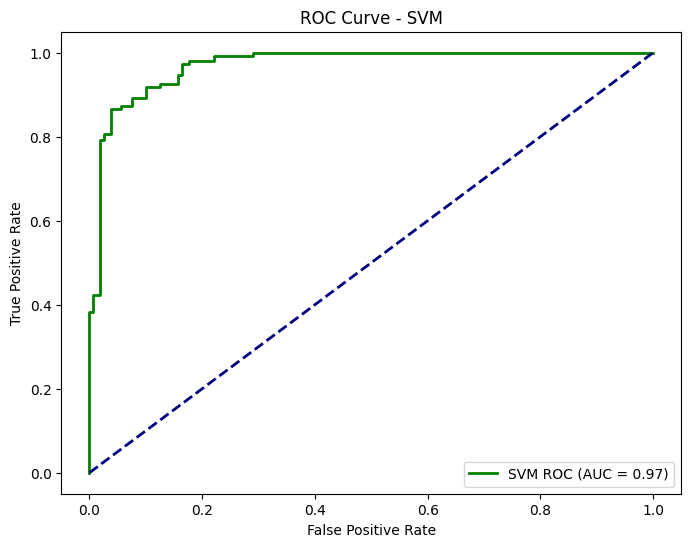

KNN Accuracy: 0.8571428571428571
KNN Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.83      0.86       159
           1       0.83      0.89      0.86       149

    accuracy                           0.86       308
   macro avg       0.86      0.86      0.86       308
weighted avg       0.86      0.86      0.86       308



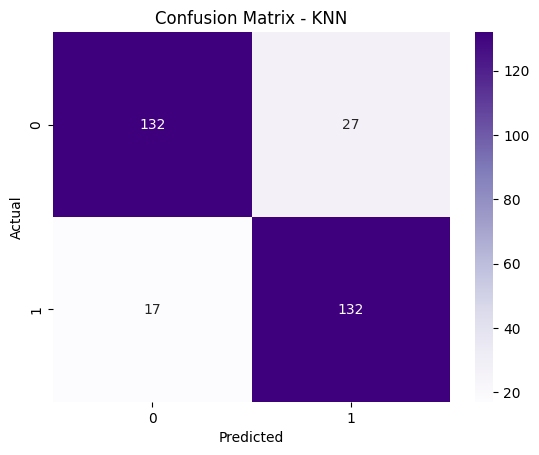

Best Decision Tree Params: {'max_depth': 9, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Accuracy: 0.9692890442890443
Tuned Decision Tree Accuracy: 0.9642857142857143
Voting Classifier Accuracy: 0.9545454545454546
Voting Classifier Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.96       159
           1       0.96      0.95      0.95       149

    accuracy                           0.95       308
   macro avg       0.95      0.95      0.95       308
weighted avg       0.95      0.95      0.95       308



In [10]:
# 13. Support Vector Machine (SVM)

from sklearn.svm import SVC

svm_model = SVC(probability=True, kernel="rbf", random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))

# ROC Curve for SVM
y_prob_svm = svm_model.predict_proba(X_test)[:,1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(8,6))
plt.plot(fpr_svm, tpr_svm, color="green", lw=2, label="SVM ROC (AUC = %0.2f)" % roc_auc_svm)
plt.plot([0,1],[0,1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend(loc="lower right")
plt.show()

# 14. K-Nearest Neighbors (KNN)

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN Classification Report:\n", classification_report(y_test, y_pred_knn))

# Confusion Matrix for KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 15. Hyperparameter Tuning (Decision Tree)

from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3,5,7,9],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
                           param_grid, cv=5, scoring="accuracy")
grid_search.fit(X_train, y_train)

print("Best Decision Tree Params:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

best_tree = grid_search.best_estimator_
y_pred_best_tree = best_tree.predict(X_test)
print("Tuned Decision Tree Accuracy:", accuracy_score(y_test, y_pred_best_tree))

# 16. Ensemble Voting Classifier

from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=1000)),
        ("rf", RandomForestClassifier(n_estimators=100, random_state=42)),
        ("gb", GradientBoostingClassifier(n_estimators=100, random_state=42))
    ],
    voting="soft"
)

voting_clf.fit(X_train, y_train)
y_pred_vote = voting_clf.predict(X_test)

print("Voting Classifier Accuracy:", accuracy_score(y_test, y_pred_vote))
print("Voting Classifier Report:\n", classification_report(y_test, y_pred_vote))

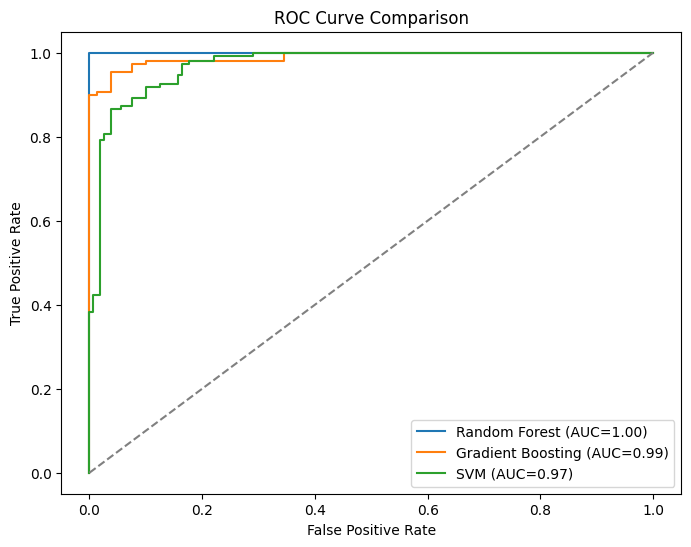

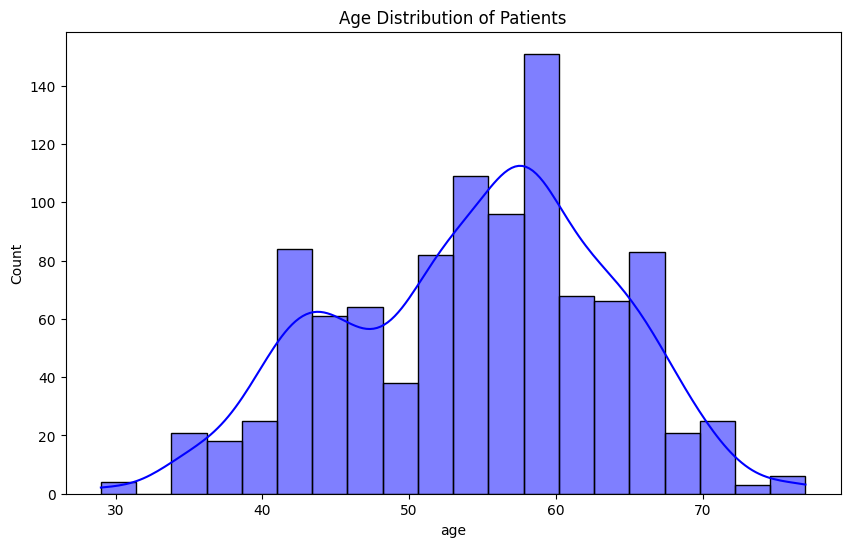

/tmp/ipykernel_12004/904341201.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y="chol", data=df, palette="Set1")


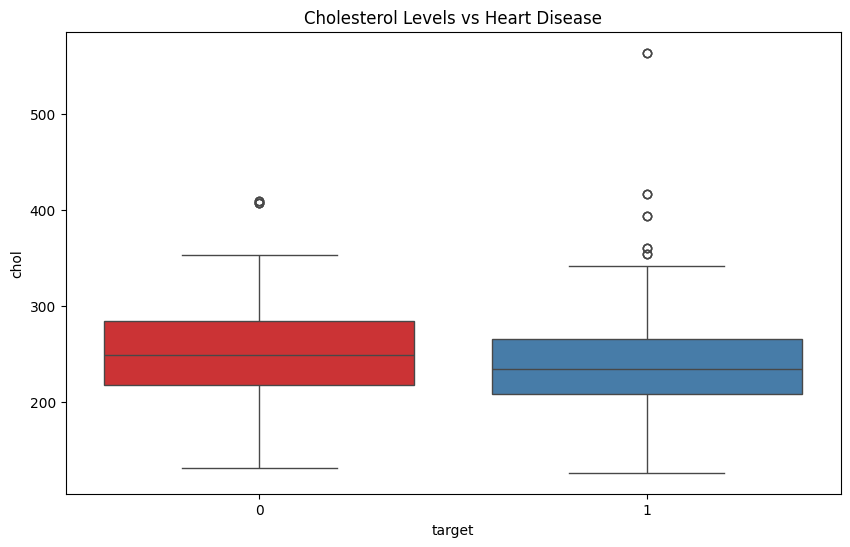

/tmp/ipykernel_12004/904341201.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="target", y="thalach", data=df, palette="Set2")


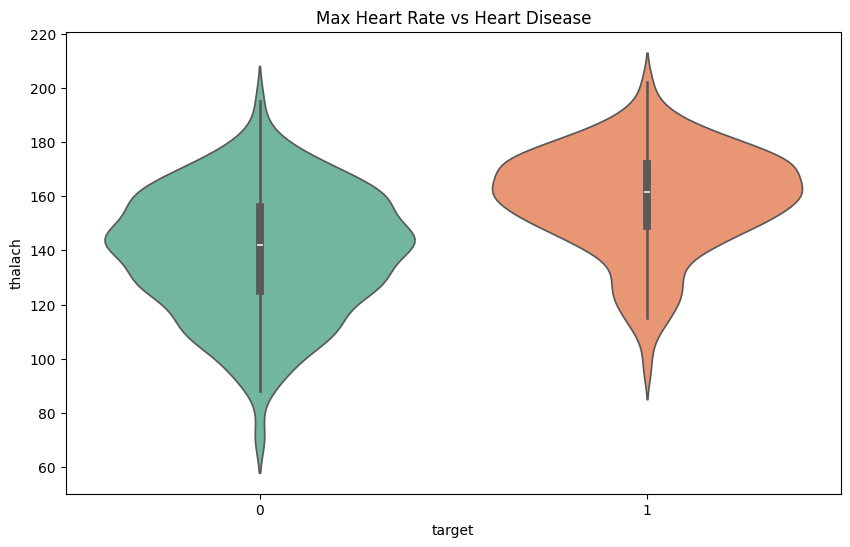

Random Forest model saved as random_forest_heart_model.pkl


In [11]:
# 17. ROC Curve Comparison

plt.figure(figsize=(8,6))

# Random Forest
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label="Random Forest (AUC=%.2f)" % roc_auc_rf)

# Gradient Boosting
y_prob_gb = gb_model.predict_proba(X_test)[:,1]
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
roc_auc_gb = auc(fpr_gb, tpr_gb)
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting (AUC=%.2f)" % roc_auc_gb)

# SVM
plt.plot(fpr_svm, tpr_svm, label="SVM (AUC=%.2f)" % roc_auc_svm)

plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.show()

# 18. Feature Distribution Plots

plt.figure(figsize=(10,6))
sns.histplot(df["age"], bins=20, kde=True, color="blue")
plt.title("Age Distribution of Patients")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x="target", y="chol", data=df, palette="Set1")
plt.title("Cholesterol Levels vs Heart Disease")
plt.show()

plt.figure(figsize=(10,6))
sns.violinplot(x="target", y="thalach", data=df, palette="Set2")
plt.title("Max Heart Rate vs Heart Disease")
plt.show()

# 19. Save Model

import joblib
joblib.dump(rf_model, "random_forest_heart_model.pkl")
print("Random Forest model saved as random_forest_heart_model.pkl")